<a href="https://colab.research.google.com/github/HTKhuongNinh-FPTU/ComputerVision-Project/blob/main/EDA_Notebook_LAB_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**PHẦN 4 — MINI RESEARCH TASK**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
from google.colab import files

# Upload và Load
uploaded = files.upload()
df = pd.read_csv(list(uploaded.keys())[0])

# Xử lý Red Flag: Tuổi âm là lỗi dữ liệu
df.loc[df['Age'] < 0, 'Age'] = np.nan

Saving titanic.csv to titanic (4).csv


--- 3. DATA QUALITY ASSESSMENT ---


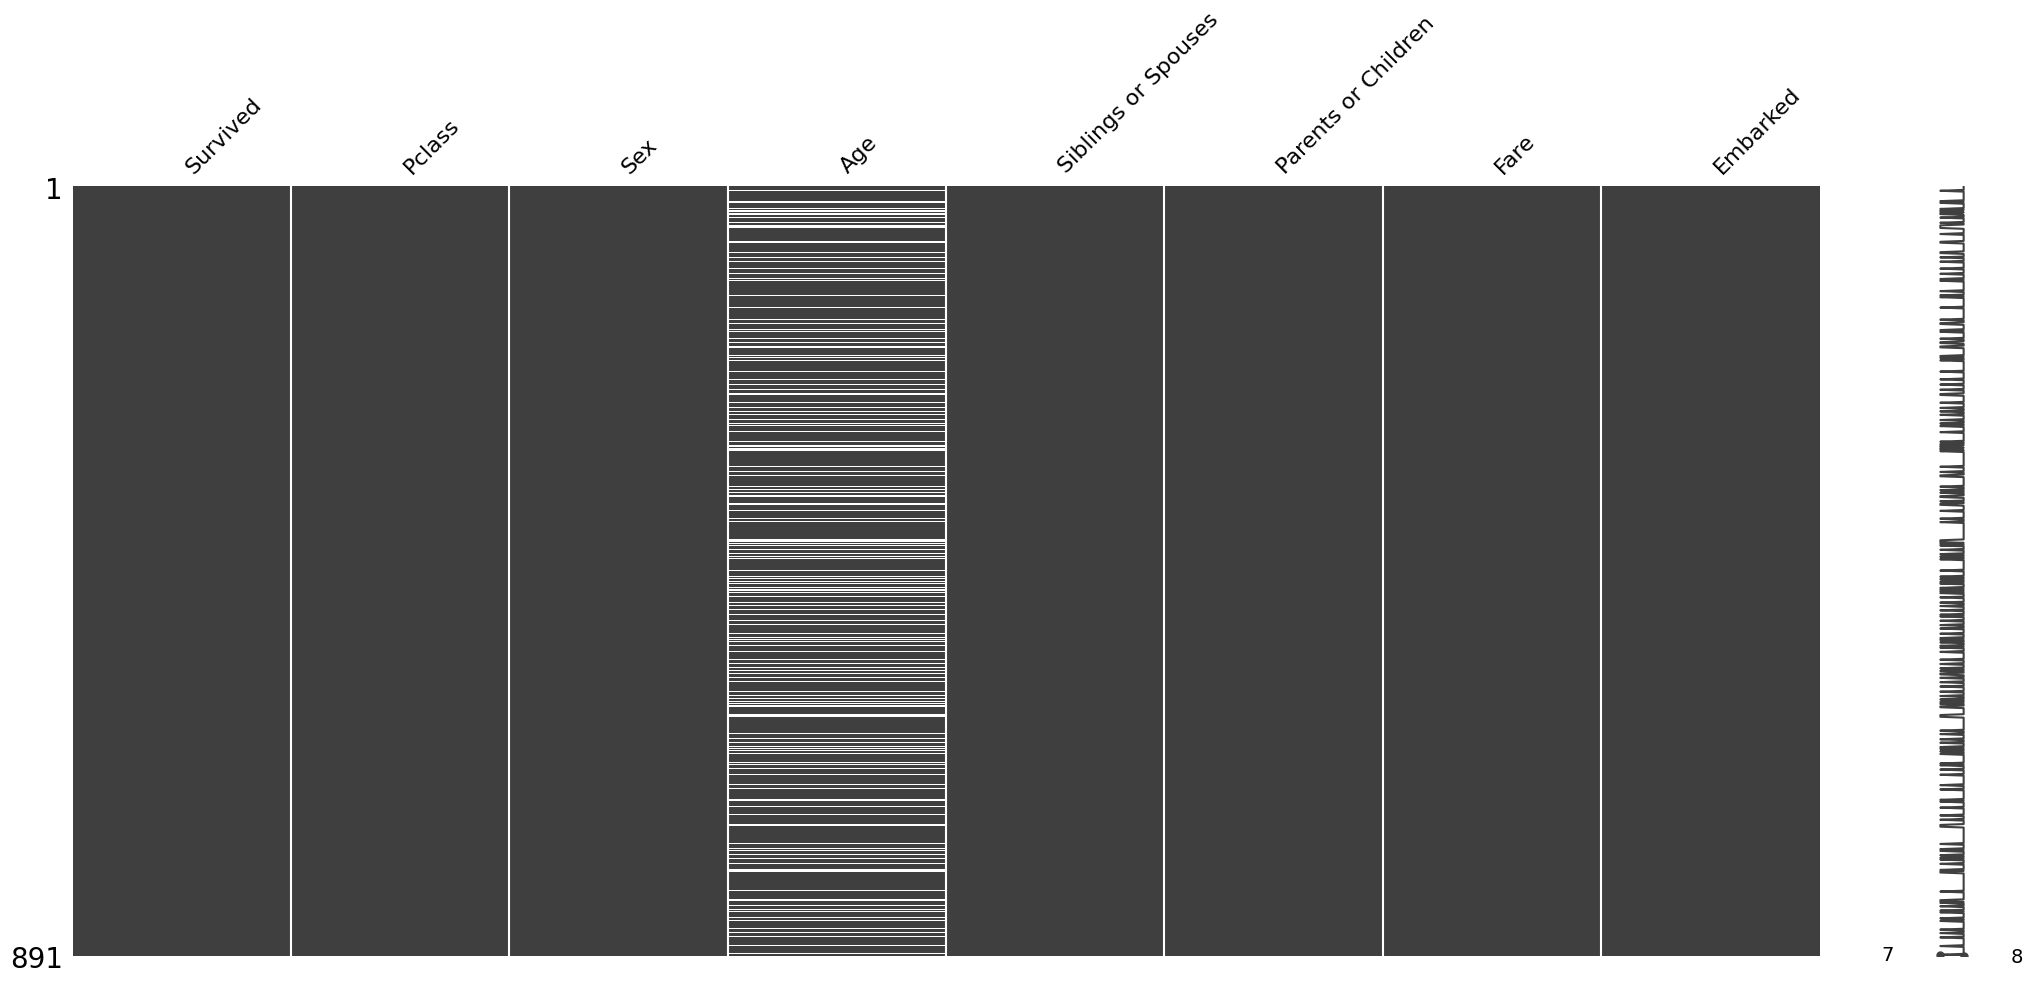

Nhận xét: Biểu đồ ma trận cho thấy cột 'Age' có một lượng đáng kể các giá trị bị thiếu.
Số dòng trùng lặp: 116


In [ ]:
# Đánh giá chất lượng
print("--- 3. DATA QUALITY ASSESSMENT ---")
msno.matrix(df)
plt.show()
print("Nhận xét: Biểu đồ ma trận cho thấy cột 'Age' có một lượng đáng kể các giá trị bị thiếu.")
print(f"Số dòng trùng lặp: {df.duplicated().sum()}")


--- 4.1 UNIVARIATE ANALYSIS ---


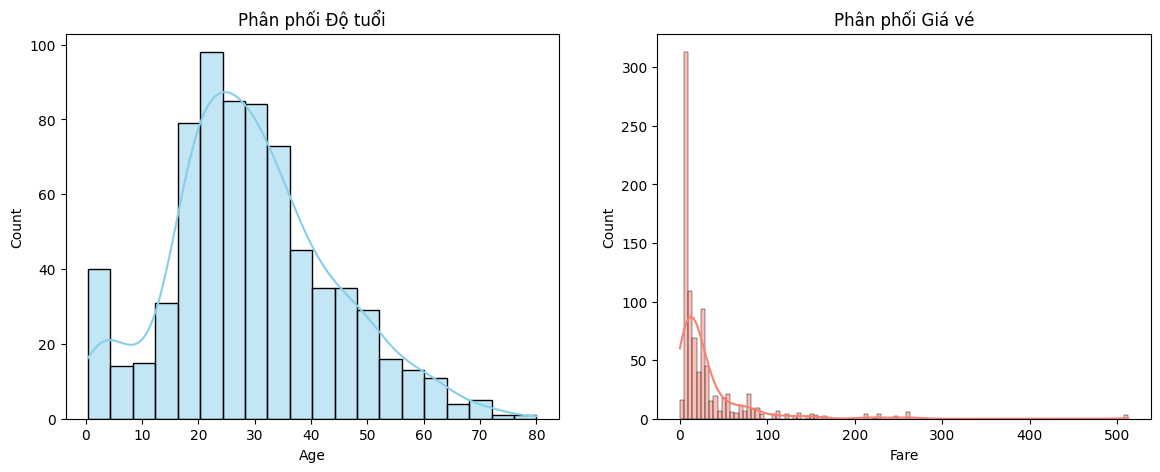

Nhận xét: Phân phối độ tuổi (Age) tập trung nhiều ở nhóm 20-40 tuổi. Phân phối giá vé (Fare) có độ lệch phải đáng kể, cho thấy đa số hành khách có giá vé thấp.


In [ ]:
# Phân tích đơn biến
print("\n--- 4.1 UNIVARIATE ANALYSIS ---")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Age'].dropna(), kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối Độ tuổi')
sns.histplot(df['Fare'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Phân phối Giá vé')
plt.show()
print("Nhận xét: Phân phối độ tuổi (Age) tập trung nhiều ở nhóm 20-40 tuổi. Phân phối giá vé (Fare) có độ lệch phải đáng kể, cho thấy đa số hành khách có giá vé thấp.")


--- 4.2 BIVARIATE & MULTIVARIATE ANALYSIS ---


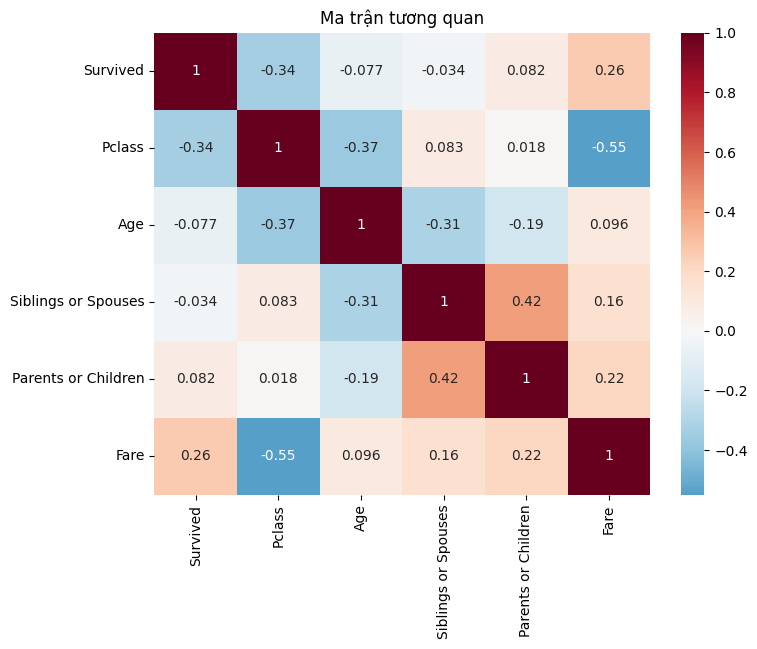

Nhận xét: Ma trận tương quan cho thấy 'Survived' có tương quan thuận mạnh với 'Fare' và tương quan nghịch mạnh với 'Pclass'. 'Age' có tương quan nghịch nhẹ với 'Survived'.


In [ ]:
# Phân tích đa biến
print("\n--- 4.2 BIVARIATE & MULTIVARIATE ANALYSIS ---")
plt.figure(figsize=(8, 6))
sns.heatmap(df.select_dtypes(include=np.number).corr(), annot=True, cmap='RdBu_r', center=0)
plt.title('Ma trận tương quan')
plt.show()
print("Nhận xét: Ma trận tương quan cho thấy 'Survived' có tương quan thuận mạnh với 'Fare' và tương quan nghịch mạnh với 'Pclass'. 'Age' có tương quan nghịch nhẹ với 'Survived'.")

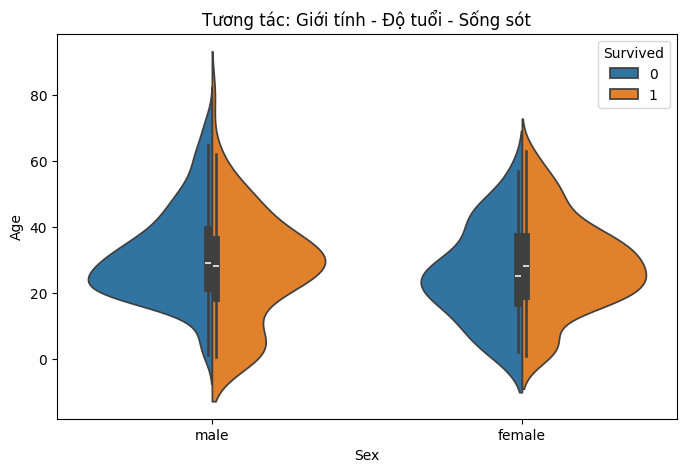

Nhận xét: Biểu đồ violin cho thấy phụ nữ, đặc biệt là những người trẻ tuổi, có tỷ lệ sống sót cao hơn nam giới ở mọi lứa tuổi.


In [ ]:
plt.figure(figsize=(8, 5))
sns.violinplot(x='Sex', y='Age', hue='Survived', data=df, split=True)
plt.title('Tương tác: Giới tính - Độ tuổi - Sống sót')
plt.show()
print("Nhận xét: Biểu đồ violin cho thấy phụ nữ, đặc biệt là những người trẻ tuổi, có tỷ lệ sống sót cao hơn nam giới ở mọi lứa tuổi.")

In [ ]:
# Tổng kết
print("\n--- 5. GIẢ THUYẾT & RED FLAGS ---")
print("- H1: Hành khách vé đắt có tỉ lệ sống sót cao hơn.")
print("- H2: Giới tính ảnh hưởng đến khả năng được cứu hộ.")
print("- Red Flags: Đã xử lý lỗi tuổi âm, cần log-transform Fare để giảm nhiễu.")


--- 5. GIẢ THUYẾT & RED FLAGS ---
- H1: Hành khách vé đắt có tỉ lệ sống sót cao hơn.
- H2: Giới tính ảnh hưởng đến khả năng được cứu hộ.
- Red Flags: Đã xử lý lỗi tuổi âm, cần log-transform Fare để giảm nhiễu.


### H1: Hành khách nữ có tỷ lệ sống sót cao hơn nam giới

**Observation:**  
Trong EDA, feature `Sex` cho thấy correlation đáng kể với `Survived`. Countplot và pairplot cũng cho thấy tỷ lệ sống sót của nữ cao hơn nam.

**Null Hypothesis (H₀):**  
Không có mối liên hệ giữa giới tính và khả năng sống sót.

**Alternative Hypothesis (H₁):**  
Giới tính có ảnh hưởng đáng kể đến khả năng sống sót.

**Proposed Test:**  
Chi-squared test hoặc Logistic Regression.

**Expected Outcome:**  
Nếu H₁ đúng, feature `Sex` sẽ có coefficient hoặc feature importance đáng kể trong model classification.

**Implication for Modeling:**  
Feature `Sex` nên được giữ lại trong modeling pipeline và có thể trở thành một trong những predictor quan trọng nhất của bài toán survival prediction.

---

### H2: Hành khách thuộc hạng vé cao có khả năng sống sót cao hơn

**Observation:**  
Boxplot và correlation heatmap cho thấy hành khách có `Fare` cao hoặc `Pclass` thấp (hạng cao hơn) thường có tỷ lệ sống sót lớn hơn.

**Null Hypothesis (H₀):**  
Không có mối liên hệ giữa hạng vé và khả năng sống sót.

**Alternative Hypothesis (H₁):**  
Hạng vé có ảnh hưởng đáng kể đến khả năng sống sót.

**Proposed Test:**  
ANOVA hoặc Logistic Regression.

**Expected Outcome:**  
Nếu H₁ đúng, các feature `Fare` và `Pclass` sẽ giúp cải thiện accuracy của model.

**Implication for Modeling:**  
Các feature liên quan đến socioeconomic status như `Fare` và `Pclass` nên được ưu tiên trong feature engineering. Có thể tạo thêm interaction feature giữa hai biến này.

---

### H3: Người lớn tuổi có tỷ lệ sống sót thấp hơn

**Observation:**  
Histogram và pairplot cho thấy nhóm hành khách lớn tuổi xuất hiện ít hơn trong nhóm sống sót.

**Null Hypothesis (H₀):**  
Tuổi không ảnh hưởng đến khả năng sống sót.

**Alternative Hypothesis (H₁):**  
Tuổi có ảnh hưởng đáng kể đến khả năng sống sót.

**Proposed Test:**  
T-test hoặc Logistic Regression.

**Expected Outcome:**  
Nếu H₁ đúng, feature `Age` sẽ có ảnh hưởng đáng kể tới probability dự đoán sống sót.

**Implication for Modeling:**  
Feature `Age` cần được xử lý cẩn thận thông qua scaling hoặc age binning. Điều này có thể giúp model học được pattern giữa các nhóm tuổi hiệu quả hơn.